PLOTTING THE CURVE_FIT COEFFICIENTS VALUE OVER GRID MAP

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import datetime
import pickle
import pandas as pd
from scipy import stats

import geopandas as gpd
from matplotlib.colors import ListedColormap
import os

Loadind data of Coefficients

In [2]:
d = pd.read_pickle("C:/PROJECT-DEMETER/Anomaly/GRID-Method/GRID-FB-UP_ICE/set1-fb_1.pkl")

In [3]:
import pandas as pd


grid_ids = []
band_keys = []
q_keys = []
coefficients_a = []
coefficients_b = []
coefficients_c = []
coefficients_d = []
coefficients_e = []
y_fit= []
chi = []
datetime = []


for grid_id, grid_data in d.items():
    for band_key, band_data in grid_data.items():
        for q_key, q_data in band_data.items():
            if 'coefficients' in q_data:
                coefficients = q_data['coefficients']
                grid_ids.append(grid_id)
                band_keys.append(band_key)
                q_keys.append(q_key)
                coefficients_a.append(coefficients[0])
                coefficients_b.append(coefficients[1])
                coefficients_c.append(coefficients[2])
                coefficients_d.append(coefficients[3])
                coefficients_e.append(coefficients[4])
                y_fit.append(q_data['y_fit'])
                chi.append(q_data['chi_square'])
                # datetime.append(q_data['datetime'])


df = pd.DataFrame({
    'Grid_ID': grid_ids,
    'Band_Key': band_keys,
    'Q_Key': q_keys,
    'Intercept': coefficients_a,
    'slope': coefficients_b,
    'Amplitude': coefficients_c,
    'Period': coefficients_d,
    'Phase': coefficients_e,
    'Y_fit': y_fit,
    'reduced-chi': chi
    # 'datetime':datetime
})

print(df)


    Grid_ID Band_Key Q_Key  Intercept     slope  Amplitude  Period      Phase  \
0       G27     fb_1    Q1  -0.246000 -0.000153   0.377151  365.25   5.025093   
1       G27     fb_1    Q2   0.236304 -0.000271   0.310246  365.25   5.031931   
2       G27     fb_1    Q3   0.842139 -0.000395   0.246383  365.25   5.471453   
3       G27     fb_1   max   1.846407 -0.000354   0.193542  365.25   5.770614   
4       G26     fb_1    Q1  -0.627177 -0.000044   0.412412  365.25  11.147066   
..      ...      ...   ...        ...       ...        ...     ...        ...   
495     G64     fb_1   max   0.150513  0.000110   0.113623  365.25   4.418358   
496    G135     fb_1    Q1  -0.302431 -0.000061   0.384512  365.25   2.188300   
497    G135     fb_1    Q2   0.172518 -0.000188   0.528928  365.25   2.016837   
498    G135     fb_1    Q3   0.882383 -0.000384   0.785133  365.25   1.846826   
499    G135     fb_1   max   2.282629 -0.000647   0.975249  365.25   1.820703   

                           

In [4]:
df['Grid_ID'].unique()


array(['G27', 'G26', 'G44', 'G62', 'G61', 'G79', 'G97', 'G115', 'G25',
       'G43', 'G42', 'G60', 'G78', 'G96', 'G114', 'G113', 'G24', 'G23',
       'G41', 'G59', 'G77', 'G95', 'G94', 'G112', 'G130', 'G22', 'G40',
       'G58', 'G76', 'G75', 'G93', 'G111', 'G129', 'G21', 'G39', 'G57',
       'G56', 'G74', 'G92', 'G110', 'G128', 'G127', 'G20', 'G38', 'G37',
       'G55', 'G73', 'G91', 'G109', 'G126', 'G144', 'G35', 'G53', 'G71',
       'G89', 'G88', 'G106', 'G124', 'G142', 'G141', 'G34', 'G52', 'G70',
       'G87', 'G105', 'G123', 'G140', 'G33', 'G51', 'G68', 'G86', 'G104',
       'G122', 'G139', 'G32', 'G49', 'G67', 'G85', 'G103', 'G120', 'G138',
       'G30', 'G48', 'G66', 'G84', 'G101', 'G119', 'G137', 'G29', 'G47',
       'G65', 'G82', 'G100', 'G118', 'G136', 'G28', 'G46', 'G63', 'G81',
       'G99', 'G117', 'G134', 'G45', 'G80', 'G98', 'G116', 'G133', 'G131',
       'G19', 'G108', 'G36', 'G54', 'G72', 'G90', 'G107', 'G125', 'G143',
       'G69', 'G50', 'G121', 'G31', 'G102', 'G83'

In [5]:

# Assuming your DataFrame is named df
q = 'Q1'
Band_Key = 'fb_1'
# Filter the DataFrame for the specific conditions
new_df = df[(df['Band_Key'] == Band_Key) & (df['Q_Key'] == q)]

# Keep only the required columns
new_df = new_df[['Grid_ID', 'Band_Key', 'Q_Key', 'Intercept', 'slope', 'Amplitude', 'Period','Phase', 'reduced-chi']]

# Reset the index of the new DataFrame
new_df.reset_index(drop=True, inplace=True)
new_df = new_df.set_index('Grid_ID')
print(new_df)


        Band_Key Q_Key  Intercept     slope  Amplitude  Period      Phase  \
Grid_ID                                                                     
G27         fb_1    Q1  -0.246000 -0.000153   0.377151  365.25   5.025093   
G26         fb_1    Q1  -0.627177 -0.000044   0.412412  365.25  11.147066   
G44         fb_1    Q1  -1.109543  0.000073   0.327988  365.25   4.823993   
G62         fb_1    Q1  -1.050625  0.000060   0.278086  365.25   4.818832   
G61         fb_1    Q1  -0.839993 -0.000042   0.221180  365.25   4.842368   
...          ...   ...        ...       ...        ...     ...        ...   
G31         fb_1    Q1   2.188597 -0.000367   0.591337  365.25   5.476918   
G102        fb_1    Q1  -0.980566  0.000054   0.094623  365.25   2.640074   
G83         fb_1    Q1  -0.903298  0.000039   0.049520  365.25   2.805723   
G64         fb_1    Q1  -0.975967  0.000110   0.160423  365.25   4.448730   
G135        fb_1    Q1  -0.302431 -0.000061   0.384512  365.25   2.188300   

C:\Users\mbabu\AppData\Local\Temp\ipykernel_112192\2369504936.py:28: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


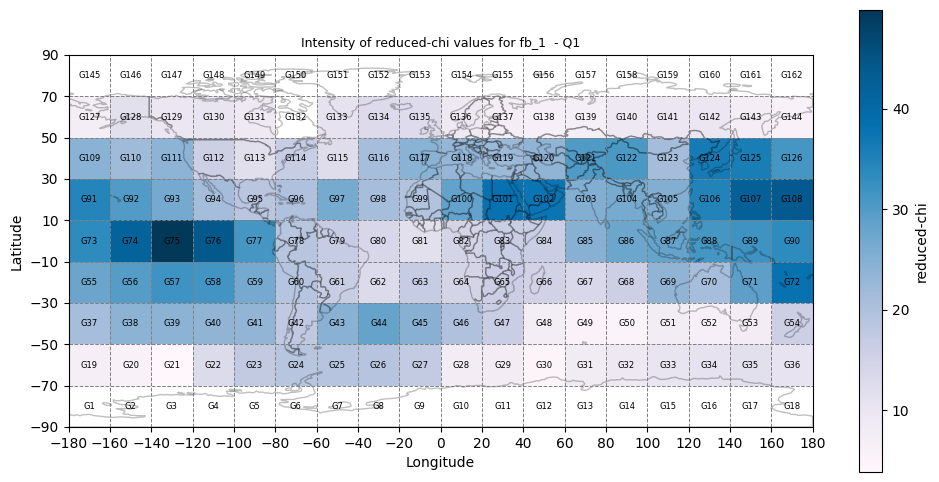

In [6]:


def create_grid(width, depth):

    min_lat, max_lat = -90, 90
    min_lon, max_lon = -180 , 180

    num_lat_cells = int((max_lat - min_lat) / depth)
    num_lon_cells = int((max_lon - min_lon) / width)

    grid = np.empty((num_lat_cells, num_lon_cells), dtype=object)
    
    # Assign IDs to each grid cell
    for lon_idx in range(num_lon_cells):
        for lat_idx in range(num_lat_cells):
            grid[lat_idx, lon_idx] = f'G{lat_idx * num_lon_cells + lon_idx + 1}'

    return grid


def plot_grid_with_intensity(grid, width, depth, all_data, intensity_column):
    fig, ax = plt.subplots(figsize=(12, 6))

    cmap = 'Reds'
    cmap = 'Oranges'
    cmap = 'Greens'
    cmap = 'PuBu'
    # cmap = 'copper_r'
    # cmap = 'Oranges'
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    world.plot(ax=ax, facecolor='none', edgecolor='black', cmap=cmap, alpha=0.25, zorder=2)
    for lat in np.arange(-90, 91, depth):
        ax.axhline(y=lat, color='gray', linestyle='--', linewidth=0.7)

    # Plot longitude lines
    for lon in np.arange(0, 361, width):  # Adjusted range to match grid calculation
        ax.axvline(x=lon - 180, color='gray', linestyle='--', linewidth=0.7)
    # Calculate the intensity of q1 mean for each grid cell
    intensities = np.zeros(grid.shape)

    for lon_idx in range(grid.shape[1]):
        for lat_idx in range(grid.shape[0]):
            specific_key = grid[lat_idx, lon_idx]
            intensity = all_data.loc[specific_key, intensity_column] if specific_key in all_data.index else np.nan
            intensities[lat_idx, lon_idx] = intensity

    im = ax.imshow(intensities, cmap=cmap, extent=[-180, 180, -90, 90], origin='lower')


    cbar = plt.colorbar(im, ax=ax)
    # im.set_clim(vmin=-3.5, vmax=1)
    cbar.set_label(intensity_column)

    # Plot grid IDs
    for lon_idx in range(grid.shape[1]):
        for lat_idx in range(grid.shape[0]):
            lat_start = -90 + lat_idx * depth
            lon_start = lon_idx * width
            ax.text(lon_start + width / 2 - 180, lat_start + depth / 2, grid[lat_idx, lon_idx], ha='center', va='center', color='black', fontsize= 6)

    ax.set_xticks(np.arange(-180, 181, 20))
    ax.set_yticks(np.arange(-90, 91, 20))


    ax.set_title(f'Intensity of {intensity_column} values for {Band_Key}  - {q}', fontsize =9)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    folder_path = f"C:\\PROJECT-DEMETER\\Anomaly\\GRID-Method\\GRID-FB-UP_ICE\\Set1-params\\{Band_Key}"

    os.makedirs(folder_path, exist_ok=True)
    plt.savefig(os.path.join(folder_path, f'{q}_{intensity_column}.png'))
    plt.show()



grid = create_grid(20, 20)

# Plot grid with intensity
plot_grid_with_intensity(grid, 20, 20, new_df, 'reduced-chi')


Plot for all params together

C:\Users\mbabu\AppData\Local\Temp\ipykernel_112192\1997082452.py:6: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


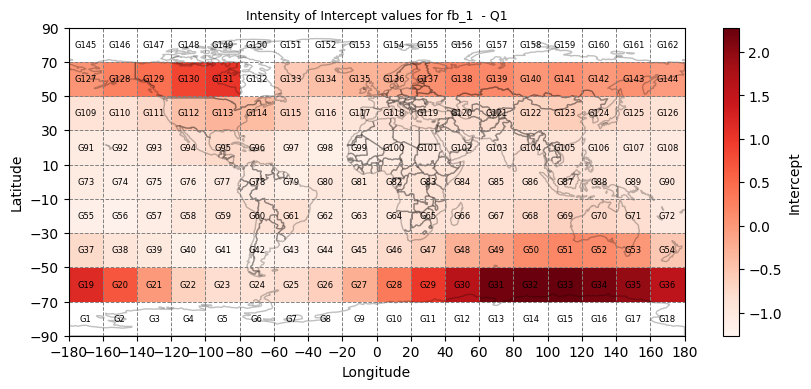

C:\Users\mbabu\AppData\Local\Temp\ipykernel_112192\1997082452.py:6: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


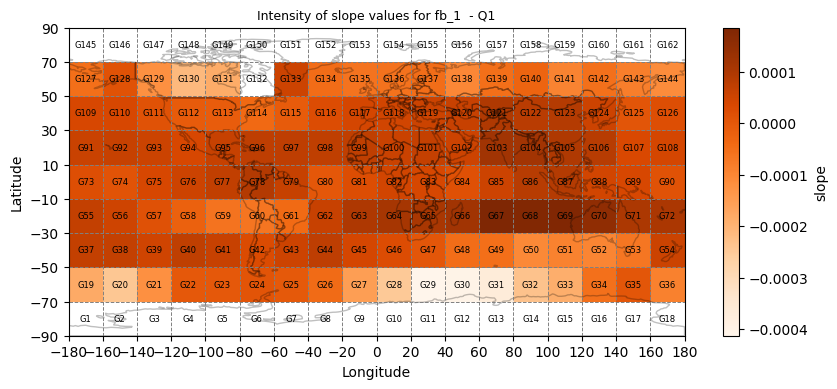

C:\Users\mbabu\AppData\Local\Temp\ipykernel_112192\1997082452.py:6: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


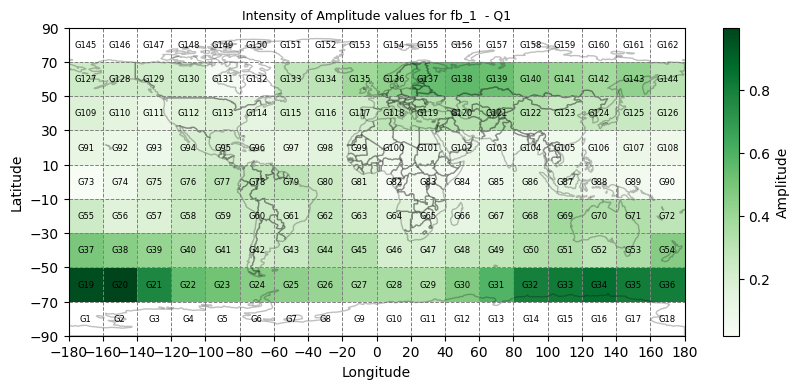

C:\Users\mbabu\AppData\Local\Temp\ipykernel_112192\1997082452.py:6: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


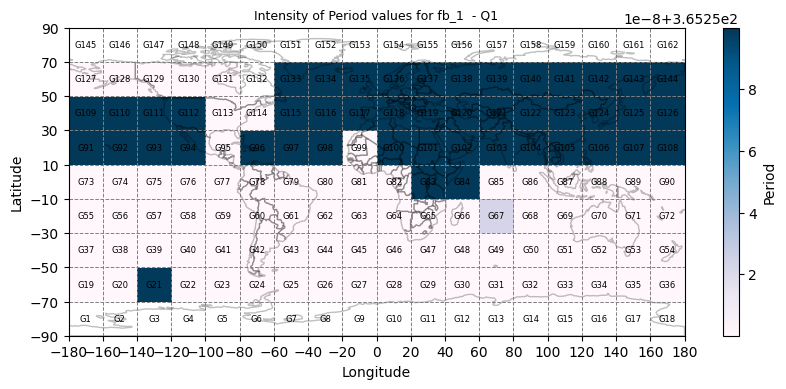

C:\Users\mbabu\AppData\Local\Temp\ipykernel_112192\1997082452.py:6: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


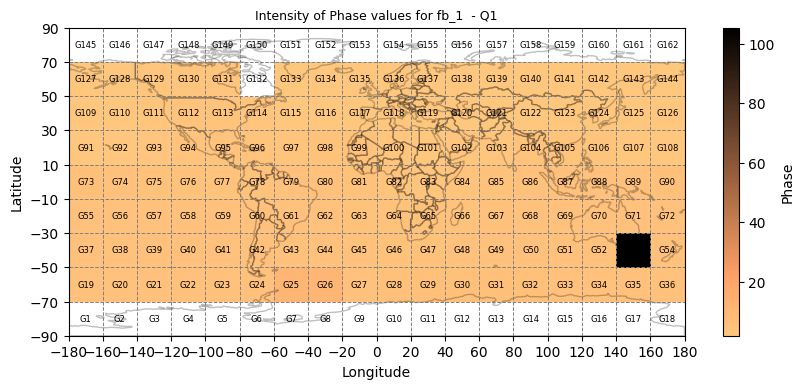

C:\Users\mbabu\AppData\Local\Temp\ipykernel_112192\1997082452.py:6: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


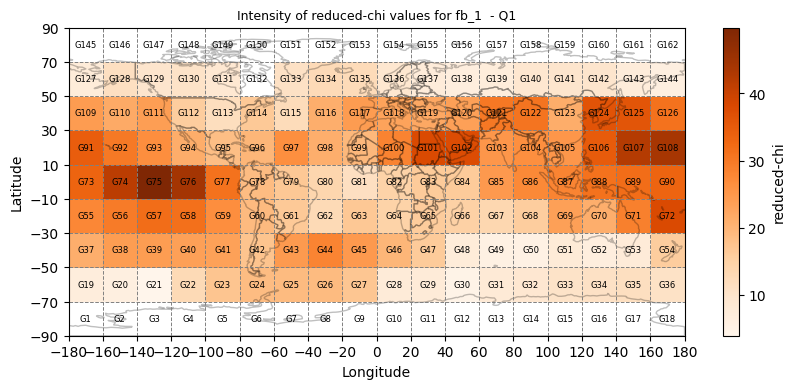

In [7]:


def plot_grid_with_intensity(grid, width, depth, all_data, intensity_column ,cmap):
    fig, ax = plt.subplots(figsize=(10, 4))

    # List of colormaps to cycle through

    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    world.plot(ax=ax, facecolor='none', edgecolor='black', alpha=0.25, zorder=2)

    for lat in np.arange(-90, 91, depth):
        ax.axhline(y=lat, color='gray', linestyle='--', linewidth=0.7)

    for lon in np.arange(0, 361, width):
        ax.axvline(x=lon - 180, color='gray', linestyle='--', linewidth=0.7)

    intensities = np.zeros(grid.shape)

    for lon_idx in range(grid.shape[1]):
        for lat_idx in range(grid.shape[0]):
            specific_key = grid[lat_idx, lon_idx]
            intensity = all_data.loc[specific_key, intensity_column] if specific_key in all_data.index else np.nan
            intensities[lat_idx, lon_idx] = intensity

    # Use the colormap from the list
    # cmap = colormaps[cmap_index % len(colormaps)]
    im = ax.imshow(intensities, cmap=cmap, extent=[-180, 180, -90, 90], origin='lower')

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(intensity_column)

    for lon_idx in range(grid.shape[1]):
        for lat_idx in range(grid.shape[0]):
            lat_start = -90 + lat_idx * depth
            lon_start = lon_idx * width
            ax.text(lon_start + width / 2 - 180, lat_start + depth / 2, grid[lat_idx, lon_idx], ha='center', va='center', color='black', fontsize=6)

    ax.set_xticks(np.arange(-180, 181, 20))
    ax.set_yticks(np.arange(-90, 91, 20))

    ax.set_title(f'Intensity of {intensity_column} values for {Band_Key}  - {q}', fontsize=9)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    folder_path = f"C:\\PROJECT-DEMETER\\Anomaly\\GRID-Method\\GRID-FB-UP_ICE\\Set1-params\\{Band_Key}"

    os.makedirs(folder_path, exist_ok=True)
    plt.savefig(os.path.join(folder_path, f'{q}_{intensity_column}.png'))
    plt.show()

 
    

grid = create_grid(20, 20)
params = ['Intercept', 'slope', 'Amplitude', 'Period','Phase', 'reduced-chi']
i = 0

for param in params:
    colormaps = ['Reds', 'Oranges', 'Greens', 'PuBu', 'copper_r', 'Oranges']

    cmap = colormaps[i]
    plot_grid_with_intensity(grid, 20, 20, new_df, param, cmap)
    i += 1


In [11]:

# Assuming your DataFrame is named df
q = 'max'
Band_Key = 'fb_1'
# Filter the DataFrame for the specific conditions
new_df =df[(df['Band_Key'] == Band_Key) & (df['Q_Key'] == q)]

# Keep only the required columns
new_df = new_df[['Grid_ID', 'Band_Key', 'Q_Key', 'Intercept', 'slope', 'Amplitude', 'Period','Phase', 'reduced-chi']]

# Reset the index of the new DataFrame
new_df.reset_index(drop=True, inplace=True)
new_df = new_df.set_index('Grid_ID')
print(new_df)


        Band_Key Q_Key  Intercept     slope  Amplitude  Period     Phase  \
Grid_ID                                                                    
G27         fb_1   max   1.846407 -0.000354   0.193542  365.25  5.770614   
G26         fb_1   max   1.483866 -0.000375   0.178005  365.25  5.508134   
G44         fb_1   max   0.059190  0.000034   0.341915  365.25  4.835486   
G62         fb_1   max   0.018004  0.000093   0.211676  365.25  4.764755   
G61         fb_1   max   0.225721  0.000063   0.130806  365.25  4.553302   
...          ...   ...        ...       ...        ...     ...       ...   
G31         fb_1   max   4.533822 -0.000485   1.101780  365.25  5.228252   
G102        fb_1   max   0.016933  0.000104   0.046892  365.25  3.138427   
G83         fb_1   max   0.230710  0.000072   0.113862  365.25  5.098643   
G64         fb_1   max   0.150513  0.000110   0.113623  365.25  4.418358   
G135        fb_1   max   2.282629 -0.000647   0.975249  365.25  1.820703   

         re

LImits Specified

C:\Users\mbabu\AppData\Local\Temp\ipykernel_112192\292354745.py:35: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


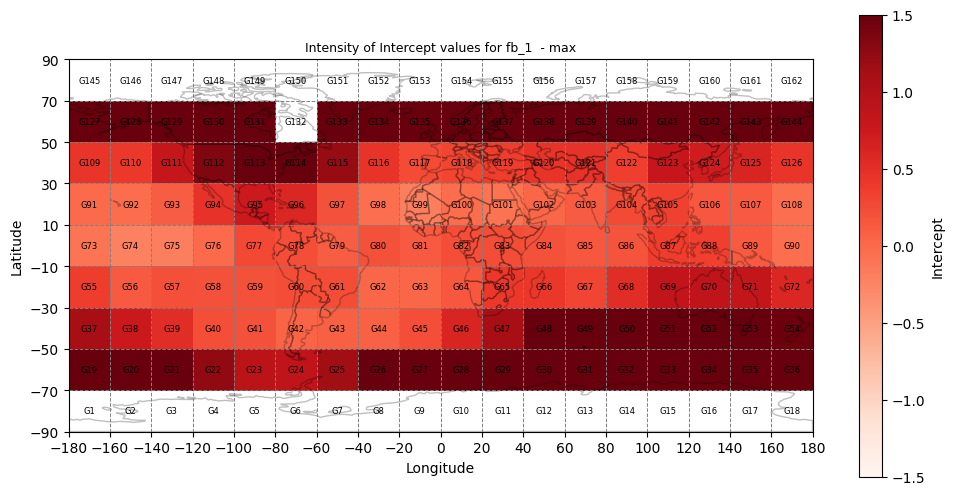

C:\Users\mbabu\AppData\Local\Temp\ipykernel_112192\292354745.py:35: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


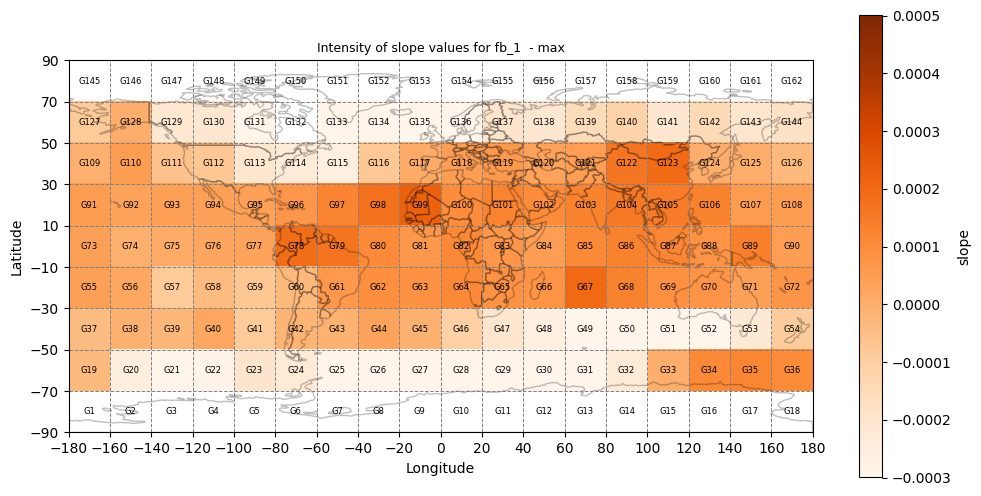

C:\Users\mbabu\AppData\Local\Temp\ipykernel_112192\292354745.py:35: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


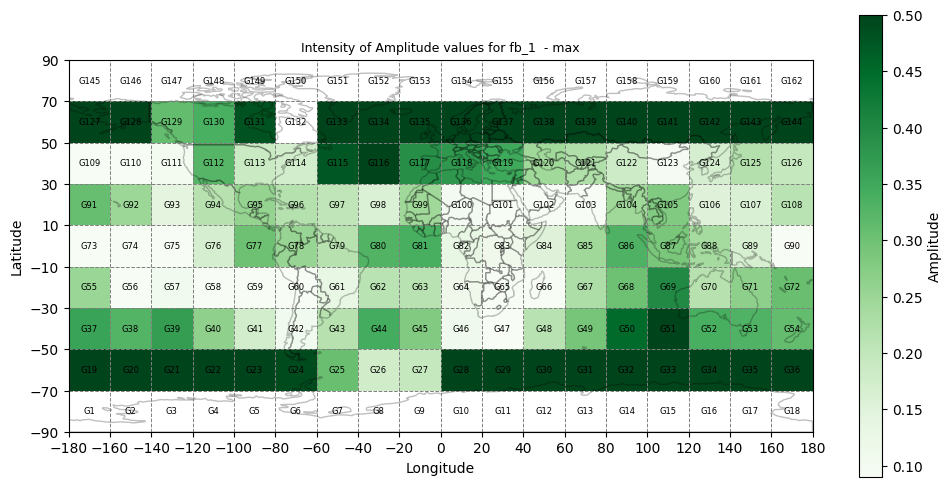

C:\Users\mbabu\AppData\Local\Temp\ipykernel_112192\292354745.py:35: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


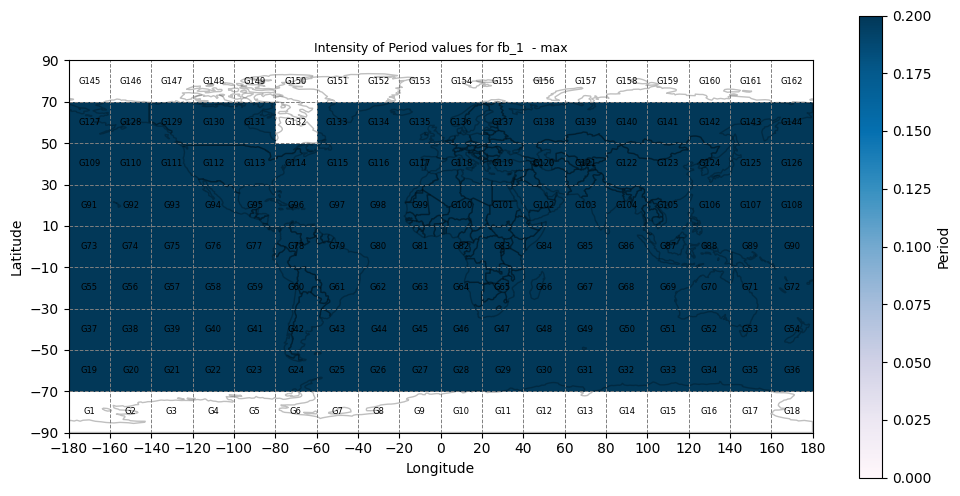

C:\Users\mbabu\AppData\Local\Temp\ipykernel_112192\292354745.py:35: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


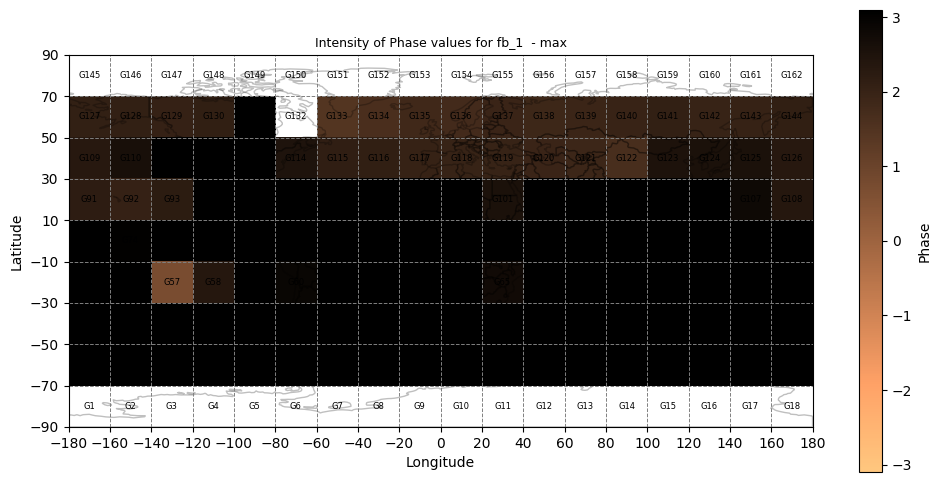

C:\Users\mbabu\AppData\Local\Temp\ipykernel_112192\292354745.py:35: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


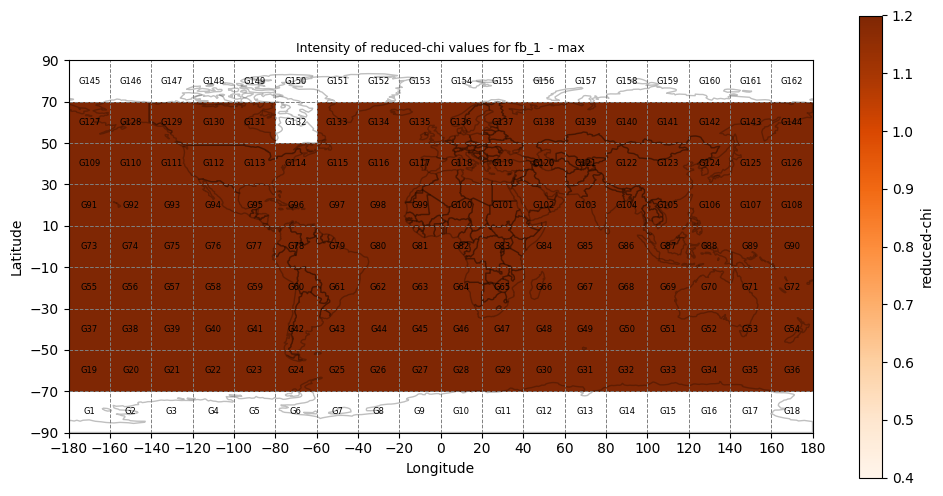

In [12]:


def plot_grid_with_intensity(grid, width, depth, all_data, intensity_column, cmap, vmin, vmax):
    fig, ax = plt.subplots(figsize=(12, 6))

    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    world.plot(ax=ax, facecolor='none', edgecolor='black', alpha=0.25, zorder=2)

    for lat in np.arange(-90, 91, depth):
        ax.axhline(y=lat, color='gray', linestyle='--', linewidth=0.7)

    for lon in np.arange(0, 361, width):
        ax.axvline(x=lon - 180, color='gray', linestyle='--', linewidth=0.7)

    intensities = np.zeros(grid.shape)

    for lon_idx in range(grid.shape[1]):
        for lat_idx in range(grid.shape[0]):
            specific_key = grid[lat_idx, lon_idx]
            intensity = all_data.loc[specific_key, intensity_column] if specific_key in all_data.index else np.nan
            intensities[lat_idx, lon_idx] = intensity

    im = ax.imshow(intensities, cmap=cmap, extent=[-180, 180, -90, 90], origin='lower', vmin=vmin, vmax=vmax)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(intensity_column)

    for lon_idx in range(grid.shape[1]):
        for lat_idx in range(grid.shape[0]):
            lat_start = -90 + lat_idx * depth
            lon_start = lon_idx * width
            ax.text(lon_start + width / 2 - 180, lat_start + depth / 2, grid[lat_idx, lon_idx], ha='center', va='center', color='black', fontsize=6)

    ax.set_xticks(np.arange(-180, 181, 20))
    ax.set_yticks(np.arange(-90, 91, 20))

    ax.set_title(f'Intensity of {intensity_column} values for {Band_Key}  - {q}', fontsize=9)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    folder_path = f"C:\\PROJECT-DEMETER\\Anomaly\\GRID-Method\\Set2-params\\{Band_Key}"

    os.makedirs(folder_path, exist_ok=True)
    # plt.savefig(os.path.join(folder_path, f'{q}_{intensity_column}-set1.png'))
    plt.show()

grid = create_grid(20, 20)
params = ['Intercept', 'slope', 'Amplitude', 'Period', 'Phase', 'reduced-chi']
vmin_vmax = {
    'Intercept': (-1.5, 1.5),
    'slope': (-0.0003, 0.0005),
    'Amplitude': (0.5, 0.1),
    'Period': (0, 0.2),
    'Phase': (-3.1, 3.1),
    'reduced-chi': (0.4, 1.2)
}
colormaps = ['Reds', 'Oranges', 'Greens', 'PuBu', 'copper_r', 'Oranges']

for i, param in enumerate(params):
    cmap = colormaps[i % len(colormaps)]
    vmin, vmax = vmin_vmax[param]
    plot_grid_with_intensity(grid, 20, 20, new_df, param, cmap, vmin, vmax)
